# <span style="color:aqua">  Data Preprocessing & Statistics</span> 


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


### <span style="color:aqua">  1. Load The Dataset</span> 

In [2]:
df = pd.read_csv('Students Social Media Addiction.csv')
df.head(10)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
5,6,19,Female,Undergraduate,Australia,7.2,Instagram,Yes,4.5,4,Complicated,5,9
6,7,23,Male,Graduate,Germany,1.5,LinkedIn,No,8.0,9,Single,0,2
7,8,20,Female,Undergraduate,Brazil,5.8,Snapchat,Yes,6.0,6,In Relationship,2,8
8,9,18,Male,High School,Japan,4.0,TikTok,No,6.5,7,Single,1,5
9,10,21,Female,Graduate,South Korea,3.3,Instagram,No,7.0,7,In Relationship,1,4


In [71]:
df.tail(5)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4
704,705,19,Female,Undergraduate,Poland,6.2,Facebook,Yes,6.3,5,Single,4,8


### <span style="color:aqua"> 2.  Data Overview</span> 

In [3]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null

In [4]:
df.shape

(705, 13)

In [5]:
print("\nSummary statistics of numerical variables:")
df.describe(include="all")


Summary statistics of numerical variables:


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705,705,705,705.000000,705,705,705.000000,705.000000,705,705.000000,705.000000
unique,NaN,NaN,2,3,110,NaN,12,2,NaN,NaN,3,NaN,NaN
top,NaN,NaN,Female,Undergraduate,India,NaN,Instagram,Yes,NaN,NaN,Single,NaN,NaN
freq,NaN,NaN,353,353,53,NaN,249,453,NaN,NaN,384,NaN,NaN
mean,353.000000,20.659574,NaN,NaN,NaN,4.918723,NaN,NaN,6.868936,6.226950,NaN,2.849645,6.436879
std,203.660256,1.399217,NaN,NaN,NaN,1.257395,NaN,NaN,1.126848,1.105055,NaN,0.957968,1.587165
min,1.000000,18.000000,NaN,NaN,NaN,1.500000,NaN,NaN,3.800000,4.000000,NaN,0.000000,2.000000
25%,177.000000,19.000000,NaN,NaN,NaN,4.100000,NaN,NaN,6.000000,5.000000,NaN,2.000000,5.000000
50%,353.000000,21.000000,NaN,NaN,NaN,4.800000,NaN,NaN,6.900000,6.000000,NaN,3.000000,7.000000
75%,529.000000,22.000000,NaN,NaN,NaN,5.800000,NaN,NaN,7.700000,7.000000,NaN,4.000000,8.000000


### <span style="color:aqua"> 3.  Data Cleaning Verification</span> 

Missing Values

In [6]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

checking For Duplicate Values

In [7]:
df.duplicated().sum()

0

Validate Data Ranges (Outlier Check)

In [8]:
df[[
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Addicted_Score"
]].describe()


,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000
mean,4.918723,6.868936,6.226950,6.436879
std,1.257395,1.126848,1.105055,1.587165
min,1.500000,3.800000,4.000000,2.000000
25%,4.100000,6.000000,5.000000,5.000000
50%,4.800000,6.900000,6.000000,7.000000
75%,5.800000,7.700000,7.000000,8.000000
max,8.500000,9.600000,9.000000,9.000000


### <span style="color:aqua"> 4. Data Transformation</span> 



#### Create Clean Working Copy

In [9]:
# Create a copy to preserve original dataset
df_clean = df.copy()

#### Encoding Categorical Variables

In [10]:
# Gender encoding
df["Gender_Encoded"] = df["Gender"].map({"Male": 0, "Female": 1})

In [11]:
# Academic Level encoding
academic_mapping = {
    "High School": 0,
    "Undergraduate": 1,
    "Graduate": 2
}
df["Academic_Level_Encoded"] = df["Academic_Level"].map(academic_mapping)

In [12]:
# Platform encoding
df["Platform_Encoded"] = df["Most_Used_Platform"].astype("category").cat.codes




In [82]:
df.head(10)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Gender_Encoded,Academic_Level_Encoded,Platform_Encoded
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8,1,1,1
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3,0,2,7
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9,1,1,6
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4,0,0,11
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7,0,2,0
5,6,19,Female,Undergraduate,Australia,7.2,Instagram,Yes,4.5,4,Complicated,5,9,1,1,1
6,7,23,Male,Graduate,Germany,1.5,LinkedIn,No,8.0,9,Single,0,2,0,2,4
7,8,20,Female,Undergraduate,Brazil,5.8,Snapchat,Yes,6.0,6,In Relationship,2,8,1,1,5
8,9,18,Male,High School,Japan,4.0,TikTok,No,6.5,7,Single,1,5,0,0,6
9,10,21,Female,Graduate,South Korea,3.3,Instagram,No,7.0,7,In Relationship,1,4,1,2,1


 Numerical features already fall in comparable ranges
 Scaling is not required for descriptive analysis
 
 Note: Scaling may be applied later if machine learning models are used.


### <span style="color:skyblue"> 5. Descriptive Statistics</span> 

#### Numerical Variables

In [13]:
numerical_stats = df[[
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Addicted_Score"
]].agg(["mean", "median", "std"])

numerical_stats


,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Addicted_Score
mean,4.918723,6.868936,6.226950,6.436879
median,4.800000,6.900000,6.000000,7.000000
std,1.257395,1.126848,1.105055,1.587165


#### Frequency Tables

Gender

In [14]:
df["Gender"].value_counts()

Gender
Female    353
Male      352
Name: count, dtype: int64

Academic_Level

In [15]:
df["Academic_Level"].value_counts()


Academic_Level
Undergraduate    353
Graduate         325
High School       27
Name: count, dtype: int64

Most use Platform

In [16]:
df["Most_Used_Platform"].value_counts()


Most_Used_Platform
Instagram    249
TikTok       154
Facebook     123
WhatsApp      54
Twitter       30
LinkedIn      21
WeChat        15
Snapchat      13
LINE          12
KakaoTalk     12
VKontakte     12
YouTube       10
Name: count, dtype: int64

### <span style="color:pink"> Interpretation of Results</span> 

- Students spend approximately 5 hours per day on social media on average.
- Median sleep duration is slightly below recommended levels, suggesting possible sleep deprivation.
- Addiction scores are relatively high, indicating notable social media dependency.
- Instagram and TikTok are the most frequently used platforms.


### <span style="color:pink"> Summary</span>

The dataset was found to be clean, complete, and free of missing or duplicate values.
Categorical variables were successfully encoded, and numerical variables were validated.
Descriptive statistics provided key insights into students’ social media usage, sleep habits,
mental health conditions, and addiction levels. The dataset is now fully prepared for
exploratory data analysis, visualization, and optional machine learning modeling.


## <span style="color:violet"> Visualization and Exploratory Data Analysis</span> 

#### <span style="color:red">1. Distribution Plots for All Numerical Variables </span>

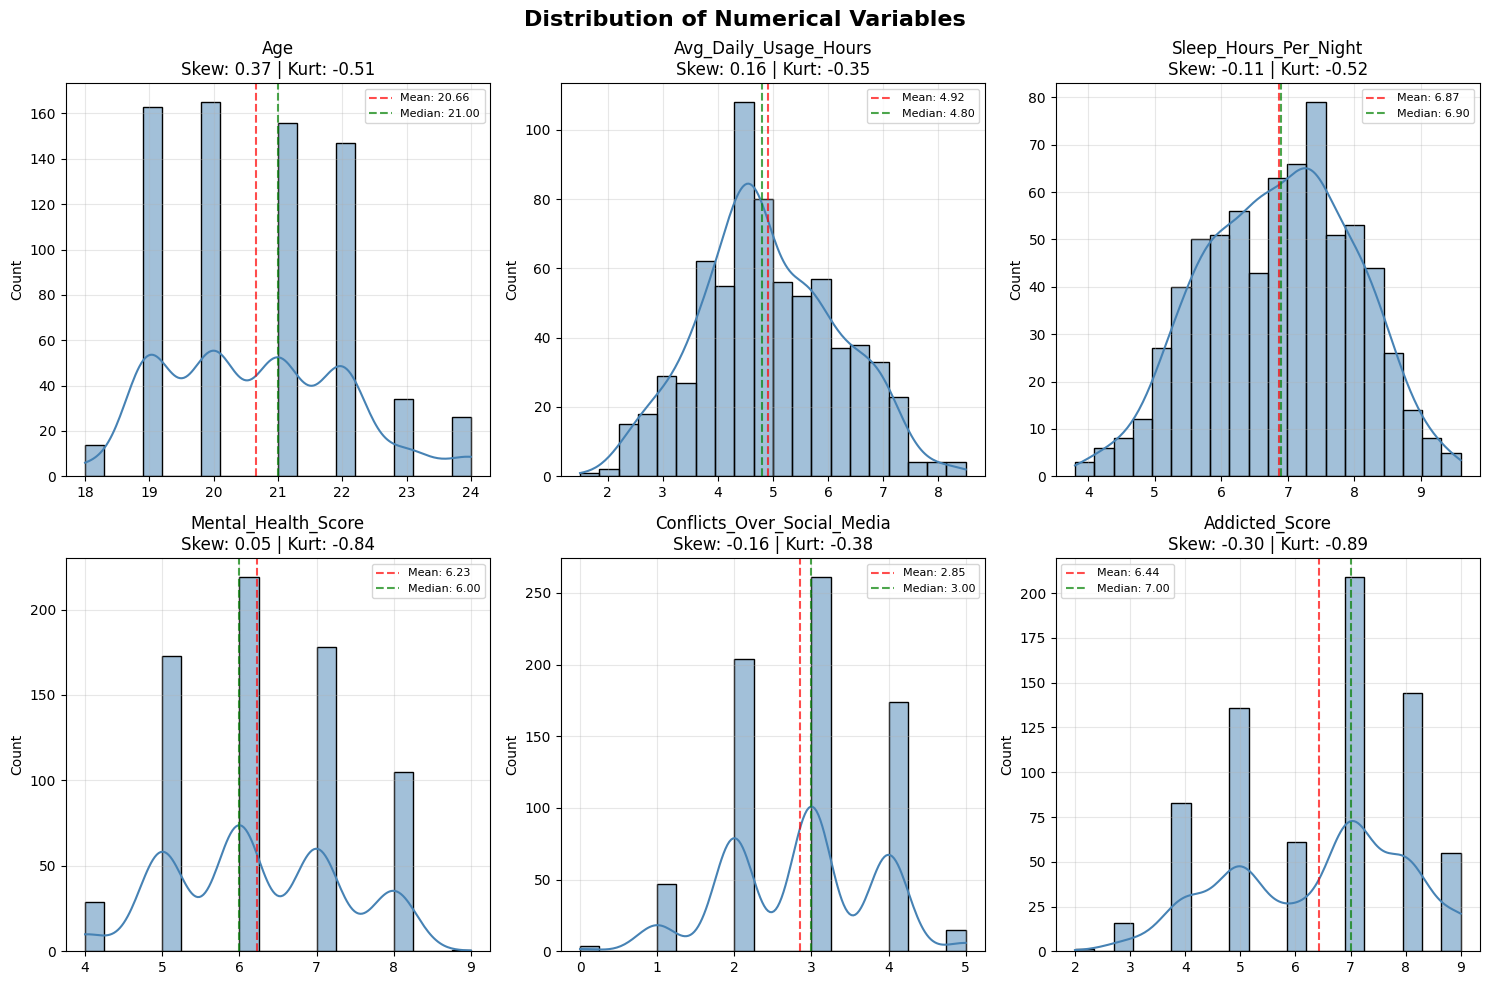

In [ ]:
num_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 
            'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Variables', fontsize=16, fontweight='bold')

for idx, col in enumerate(num_cols):
    row, col_idx = divmod(idx, 3)
    ax = axes[row, col_idx]
    
    # Histogram with KDE
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=20)
    ax.axvline(df[col].mean(), color='red', linestyle='--', 
               label=f'Mean: {df[col].mean():.2f}', alpha=0.7)
    ax.axvline(df[col].median(), color='green', linestyle='--', 
               label=f'Median: {df[col].median():.2f}', alpha=0.7)
    
    ax.set_title(f'{col}\nSkew: {df[col].skew():.2f} | Kurt: {df[col].kurtosis():.2f}')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### <span style="color:coral">2. Box Plots for Outlier Detection</span> 

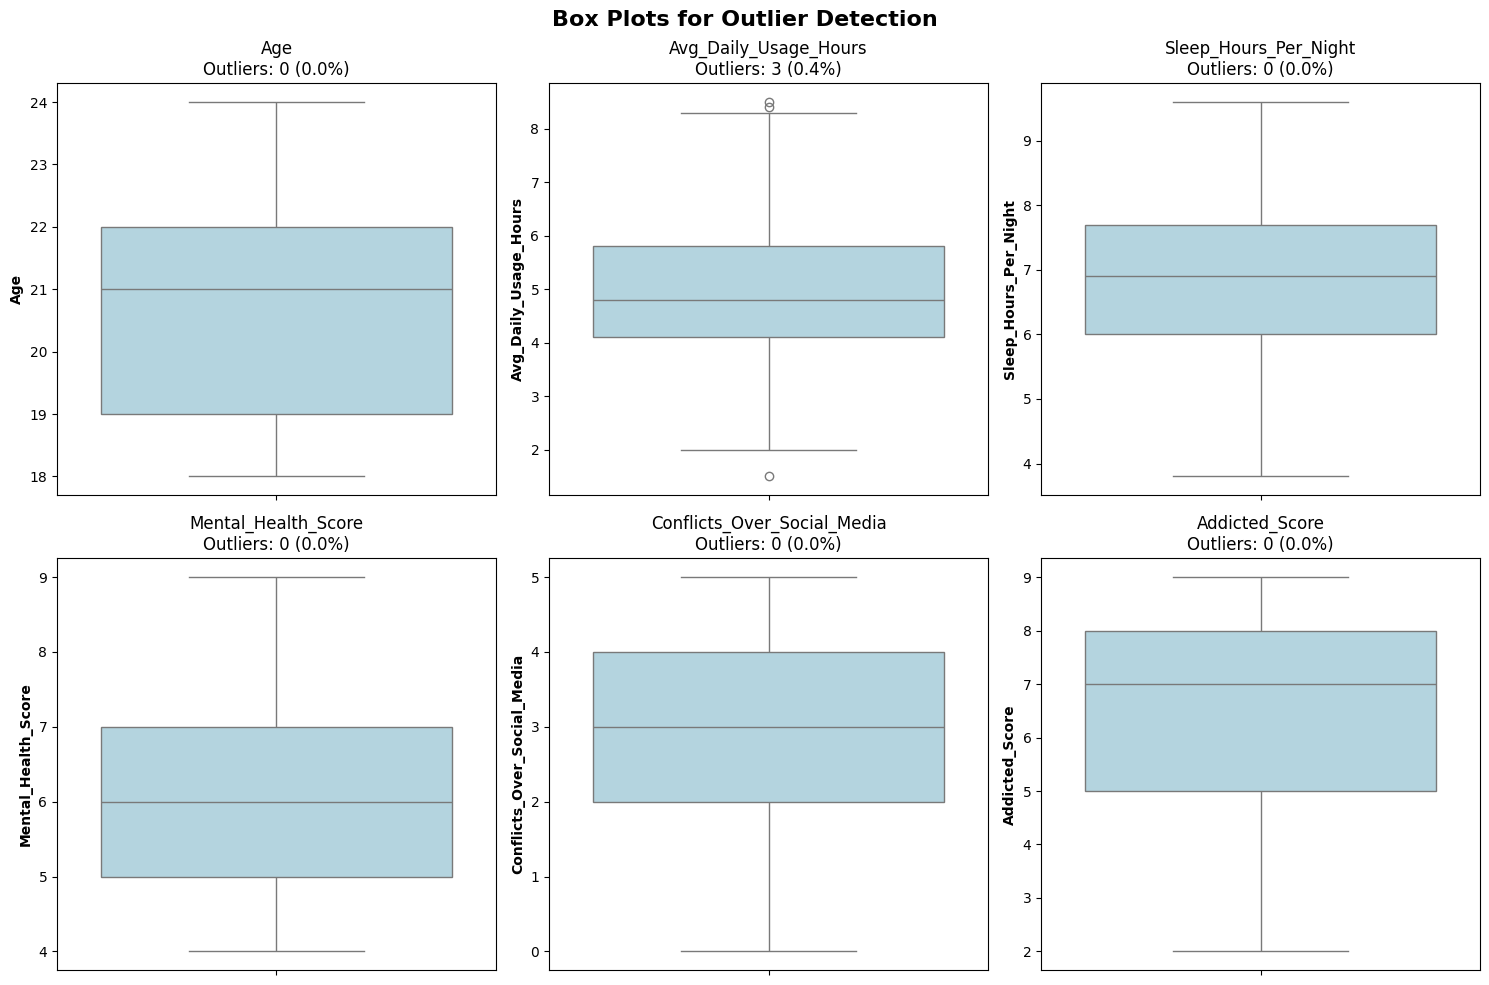

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Box Plots for Outlier Detection', fontsize=16, fontweight='bold')

for idx, col in enumerate(num_cols):
    row, col_idx = divmod(idx, 3)
    ax = axes[row, col_idx]
    
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_ylabel(col, fontweight='bold')
    
    # Add count of outliers (beyond 1.5*IQR)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    ax.set_title(f'{col}\nOutliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

plt.tight_layout()
plt.show()

checking unique values

In [ ]:
categorical_cols = [
    "Gender", 
    "Academic_Level", 
    "Country", 
    "Most_Used_Platform", 
    "Affects_Academic_Performance", 
    "Relationship_Status"
]

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].unique())
    print(f"Count of unique value : {len(df[col].unique())}")
    print()


--- Gender ---
['Female' 'Male']
Count of unique value : 2

--- Academic_Level ---
['Undergraduate' 'Graduate' 'High School']
Count of unique value : 3

--- Country ---
['Bangladesh' 'India' 'USA' 'UK' 'Canada' 'Australia' 'Germany' 'Brazil'
 'Japan' 'South Korea' 'France' 'Spain' 'Italy' 'Mexico' 'Russia' 'China'
 'Sweden' 'Norway' 'Denmark' 'Netherlands' 'Belgium' 'Switzerland'
 'Austria' 'Portugal' 'Greece' 'Ireland' 'New Zealand' 'Singapore'
 'Malaysia' 'Thailand' 'Vietnam' 'Philippines' 'Indonesia' 'Taiwan'
 'Hong Kong' 'Turkey' 'Israel' 'UAE' 'Egypt' 'Morocco' 'South Africa'
 'Nigeria' 'Kenya' 'Ghana' 'Argentina' 'Chile' 'Colombia' 'Peru'
 'Venezuela' 'Ecuador' 'Uruguay' 'Paraguay' 'Bolivia' 'Costa Rica'
 'Panama' 'Jamaica' 'Trinidad' 'Bahamas' 'Iceland' 'Finland' 'Poland'
 'Romania' 'Hungary' 'Czech Republic' 'Slovakia' 'Croatia' 'Serbia'
 'Slovenia' 'Bulgaria' 'Estonia' 'Latvia' 'Lithuania' 'Ukraine' 'Moldova'
 'Belarus' 'Kazakhstan' 'Uzbekistan' 'Kyrgyzstan' 'Tajikistan' 'Arme

#### <span style = "color:plum"> 3.X Categorical Feature Distribution Analysis</span>

This section analyzes the distribution of categorical variables in the dataset.
Bar charts are used to display frequency counts, while pie charts represent
percentage contributions. To improve readability, only the most frequent
categories are displayed, and the remaining categories are grouped under
"Others".


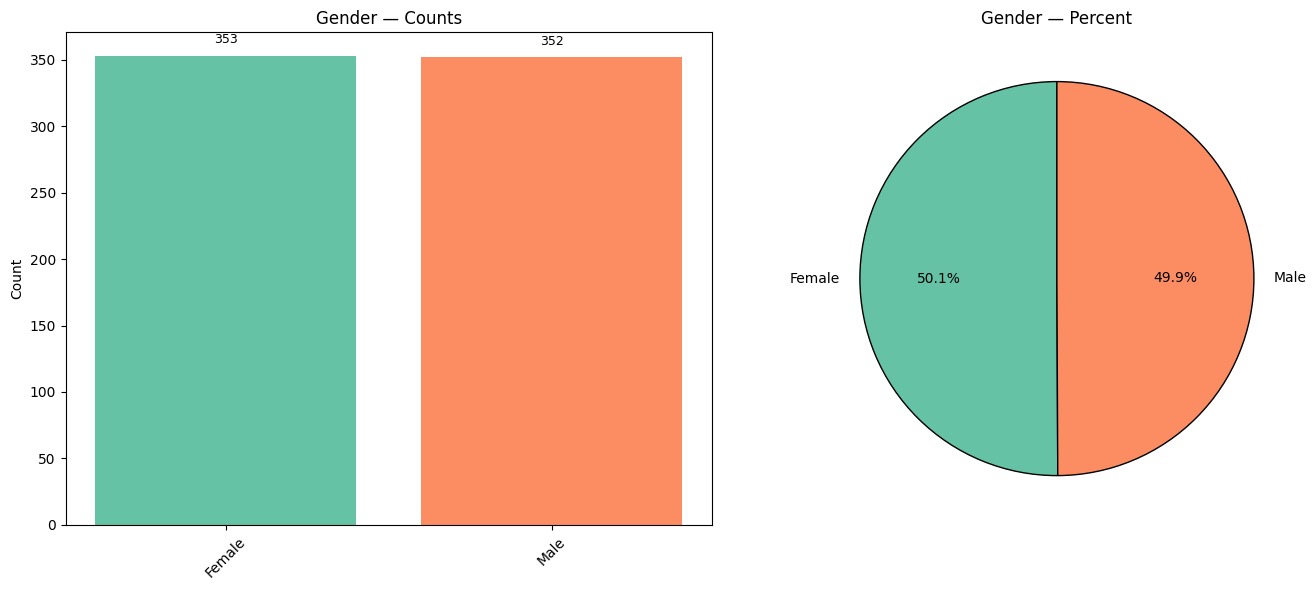


Gender:
Category  Count  Percent
  Female    353    50.07
    Male    352    49.93


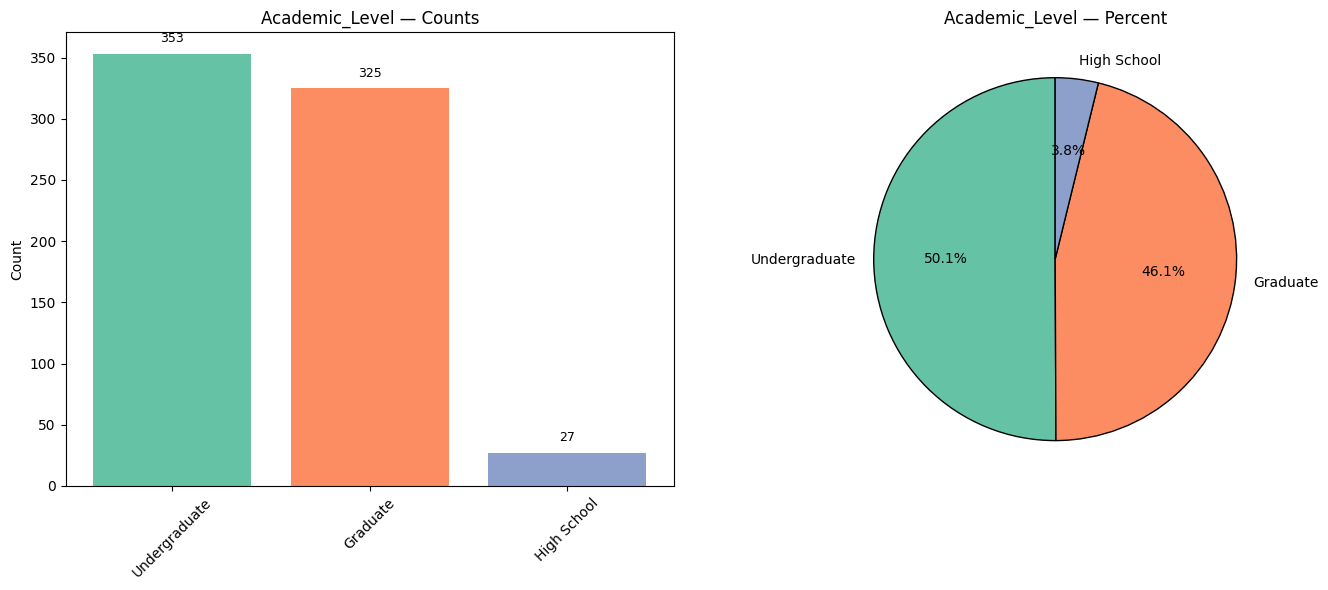


Academic_Level:
     Category  Count  Percent
Undergraduate    353    50.07
     Graduate    325    46.10
  High School     27     3.83


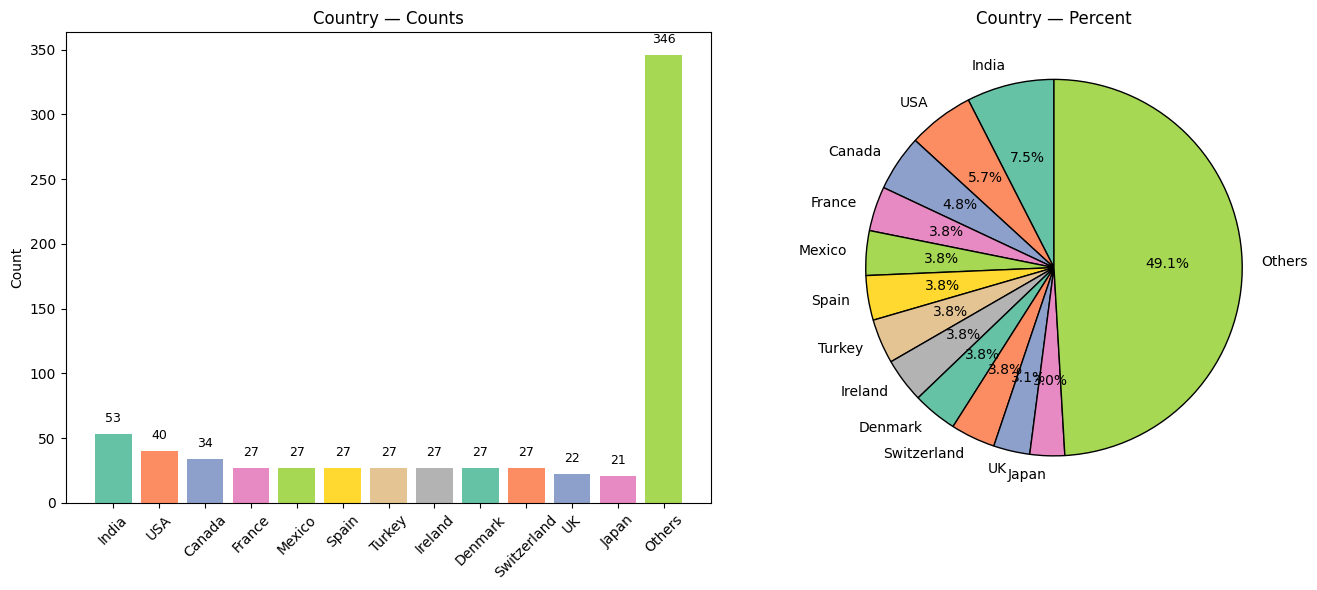


Country:
   Category  Count  Percent
      India     53     7.52
        USA     40     5.67
     Canada     34     4.82
     France     27     3.83
     Mexico     27     3.83
      Spain     27     3.83
     Turkey     27     3.83
    Ireland     27     3.83
    Denmark     27     3.83
Switzerland     27     3.83
         UK     22     3.12
      Japan     21     2.98
     Others    346    49.08


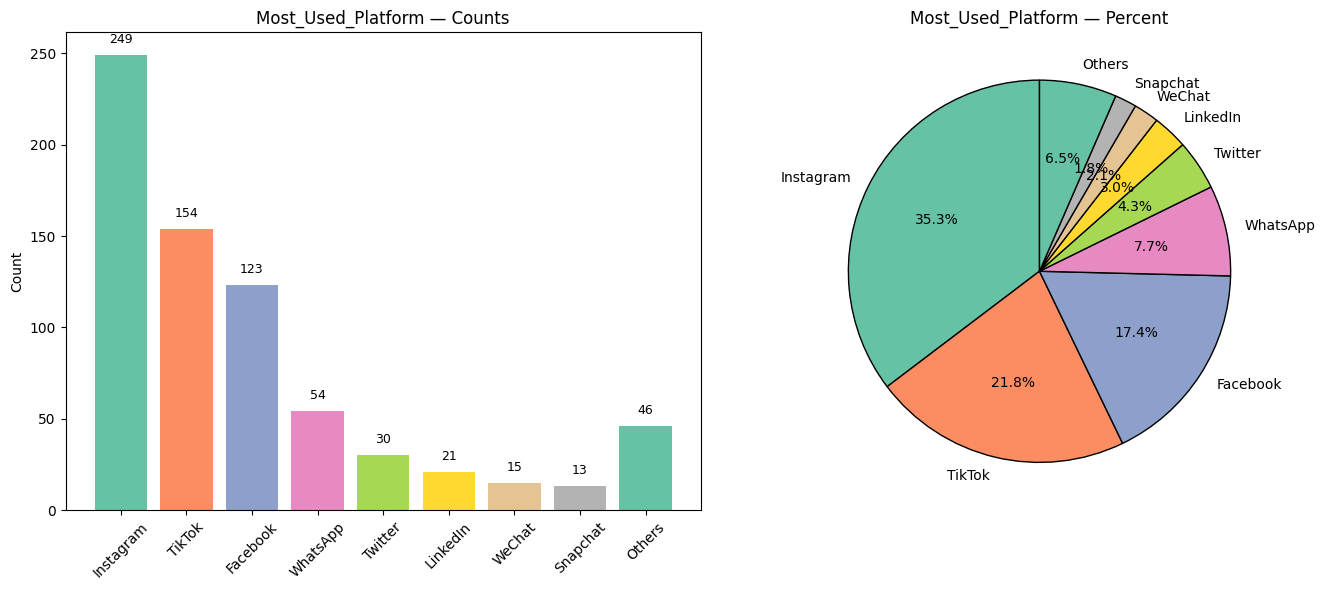


Most_Used_Platform:
 Category  Count  Percent
Instagram    249    35.32
   TikTok    154    21.84
 Facebook    123    17.45
 WhatsApp     54     7.66
  Twitter     30     4.26
 LinkedIn     21     2.98
   WeChat     15     2.13
 Snapchat     13     1.84
   Others     46     6.52


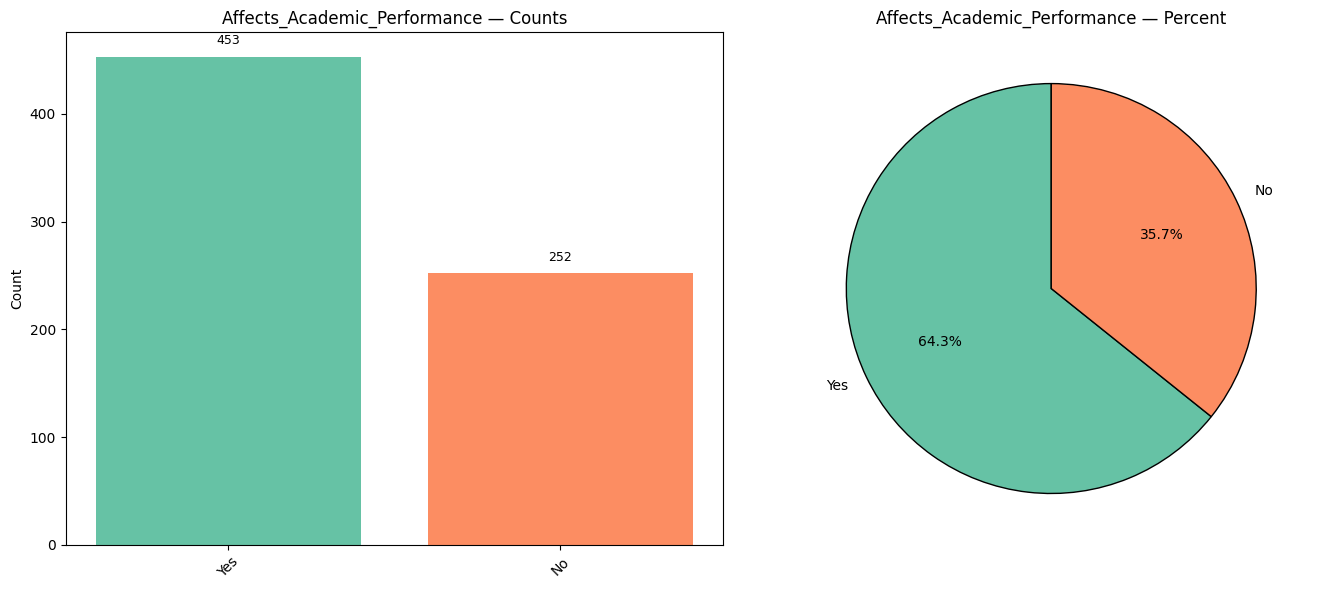


Affects_Academic_Performance:
Category  Count  Percent
     Yes    453    64.26
      No    252    35.74


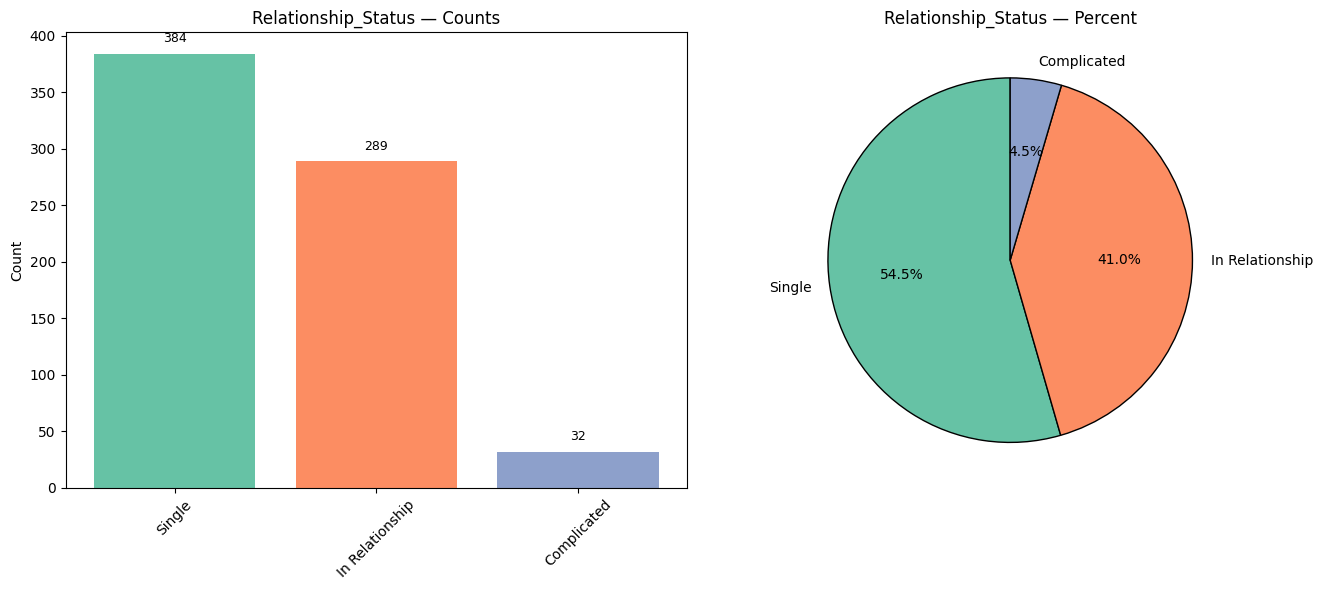


Relationship_Status:
       Category  Count  Percent
         Single    384    54.47
In Relationship    289    40.99
    Complicated     32     4.54


In [90]:
def plot_categorical_summary(df, col, top_n=10, min_freq=0):
    """
    Plot bar (counts) and pie (percent) for a categorical column.
    - Keeps top_n categories (after dropping NaNs). Others -> 'Others'.
    - Or, if min_freq > 0, anything below min_freq is grouped as 'Others'.
    Returns the frequency table (as a Series) used for plotting.
    """
    # Preprocess the data
    s = df[col].fillna("Missing").astype(str)
    vc = s.value_counts(dropna=False)

    # Group categories based on frequency threshold or top_n
    if min_freq > 0:
        major = vc[vc >= min_freq]
        others_count = vc[vc < min_freq].sum()
    else:
        major = vc.iloc[:top_n]
        others_count = vc.iloc[top_n:].sum()

    if others_count > 0:
        major["Others"] = others_count

    # Plot settings
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = sns.color_palette("Set2", len(major))
    axes[0].bar(major.index, major.values, color=colors)
    axes[0].set_title(f"{col} — Counts")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(major.values):
        axes[0].text(i, v + max(major.values)*0.02, str(int(v)), ha="center", va="bottom", fontsize=9)

    major.plot.pie(
        autopct="%1.1f%%",
        colors=colors,
        startangle=90,
        wedgeprops={"edgecolor": "black"},
        ax=axes[1]
    )
    axes[1].set_ylabel("")
    axes[1].set_title(f"{col} — Percent")

    plt.tight_layout()
    plt.show()

    # Return the frequency table
    return major

topn_map = defaultdict(lambda: 10, {
    "Most_Used_Platform": 8,
    "Country": 12
})

for col in categorical_cols:
    freq_series = plot_categorical_summary(df, col, top_n=topn_map[col], min_freq=0)
    # Print the frequency table
    freq_table = pd.DataFrame({
        'Category': freq_series.index,
        'Count': freq_series.values,
        'Percent': (freq_series.values / len(df) * 100).round(2)
    })
    print(f"\n{col}:")
    print(freq_table.to_string(index=False))

#### <span style="color:yellow">4. CROSS-TABULATION: KEY RELATIONSHIPS</span>

#### <span style="color:coral"> Platform vs Academic Impact </span>

In [39]:
cross_platform = pd.crosstab(df['Most_Used_Platform'], 
                            df['Affects_Academic_Performance'], 
                            normalize='index') * 100
print(cross_platform.round(1))

Affects_Academic_Performance     No    Yes
Most_Used_Platform                        
Facebook                       69.9   30.1
Instagram                      30.9   69.1
KakaoTalk                       0.0  100.0
LINE                          100.0    0.0
LinkedIn                      100.0    0.0
Snapchat                        7.7   92.3
TikTok                          6.5   93.5
Twitter                        63.3   36.7
VKontakte                     100.0    0.0
WeChat                         46.7   53.3
WhatsApp                        0.0  100.0
YouTube                        70.0   30.0


#### <span style="color:turquoise">Addiction Score and Academic Performance Impact </span>

In [ ]:
df_clean.groupby("Affects_Academic_Performance")["Addicted_Score"].mean()

Affects_Academic_Performance
No     4.595238
Yes    7.461369
Name: Addicted_Score, dtype: float64

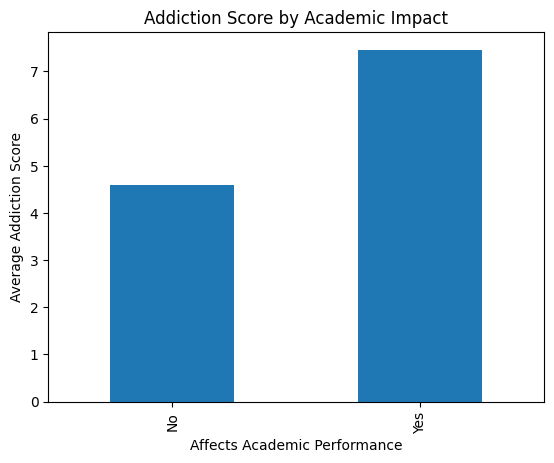

In [38]:
plt.figure()
df_clean.groupby("Affects_Academic_Performance")["Addicted_Score"].mean().plot(kind="bar")
plt.xlabel("Affects Academic Performance")
plt.ylabel("Average Addiction Score")
plt.title("Addiction Score by Academic Impact")
plt.show()



Students who report that social media affects their academic performance
have a higher average addiction score compared to those who do not.


#### <span style = "color:lightpink"> Academic Level vs Addiction Categories </span>

In [40]:
df['Addiction_Category'] = pd.cut(df['Addicted_Score'], 
                                 bins=[0, 4, 7, 10],
                                 labels=['Low (0-4)', 'Moderate (4-7)', 'High (7-10)'])
cross_academic = pd.crosstab(df['Academic_Level'], 
                            df['Addiction_Category'],
                            normalize='index') * 100
print(cross_academic.round(1))

Addiction_Category  Low (0-4)  Moderate (4-7)  High (7-10)
Academic_Level                                            
Graduate                 17.5            61.5         20.9
High School               3.7             3.7         92.6
Undergraduate            11.9            58.1         30.0


##### <span style="color:fuchsia">Gender vs Platform Preference</span>

In [41]:
print("\n3. GENDER vs PLATFORM PREFERENCE:")
cross_gender = pd.crosstab(df['Gender'], 
                          df['Most_Used_Platform'],
                          normalize='index') * 100
print(cross_gender.round(1))


3. GENDER vs PLATFORM PREFERENCE:
Most_Used_Platform  Facebook  Instagram  KakaoTalk  LINE  LinkedIn  Snapchat  \
Gender                                                                         
Female                   6.8       48.7        3.4   3.4       2.3       2.3   
Male                    28.1       21.9        0.0   0.0       3.7       1.4   

Most_Used_Platform  TikTok  Twitter  VKontakte  WeChat  WhatsApp  YouTube  
Gender                                                                     
Female                24.4      4.5        0.0     1.1       3.1      0.0  
Male                  19.3      4.0        3.4     3.1      12.2      2.8  


#### <span style="color:tan">5. Addiction score vs daily usage (scatter plot)</span>


1. ADDICTION SCORE VS DAILY USAGE


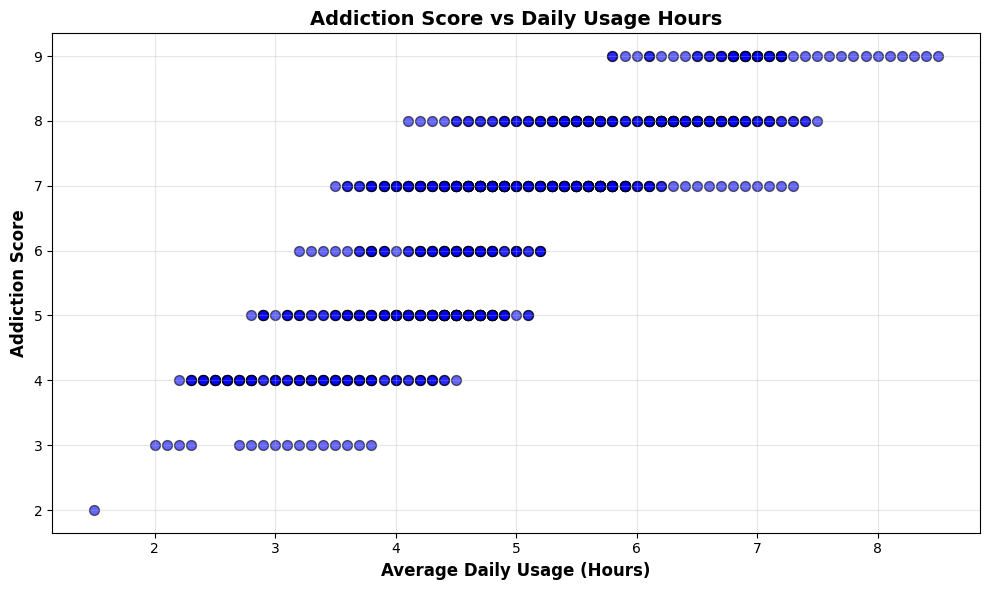

In [36]:
# 1. Addiction score vs daily usage (scatter plot)
print("\n1. ADDICTION SCORE VS DAILY USAGE")

plt.figure(figsize=(10, 6))
plt.scatter(df['Avg_Daily_Usage_Hours'], df['Addicted_Score'], 
            alpha=0.6, color='blue', edgecolors='black', s=50)
plt.xlabel('Average Daily Usage (Hours)', fontsize=12, fontweight='bold')
plt.ylabel('Addiction Score', fontsize=12, fontweight='bold')
plt.title('Addiction Score vs Daily Usage Hours', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### <span style="color:lime">  INTERPRETATION: </span>

• Strong positive relationship: More daily usage = Higher addiction scores

• 5-hour critical threshold: Students using >5 hours daily have addiction scores 7+ (high risk)

• No safe high-usage group: All heavy users (6+ hours) show high addiction (scores 7-9)

• Practical implication: Limiting usage to <3 hours keeps addiction scores <5 (low risk)

• Key finding: Time spent is the strongest predictor of addiction severity

#### <span style="color:cyan">6. Sleep hours vs addiction score </span>


2. SLEEP HOURS VS ADDICTION SCORE


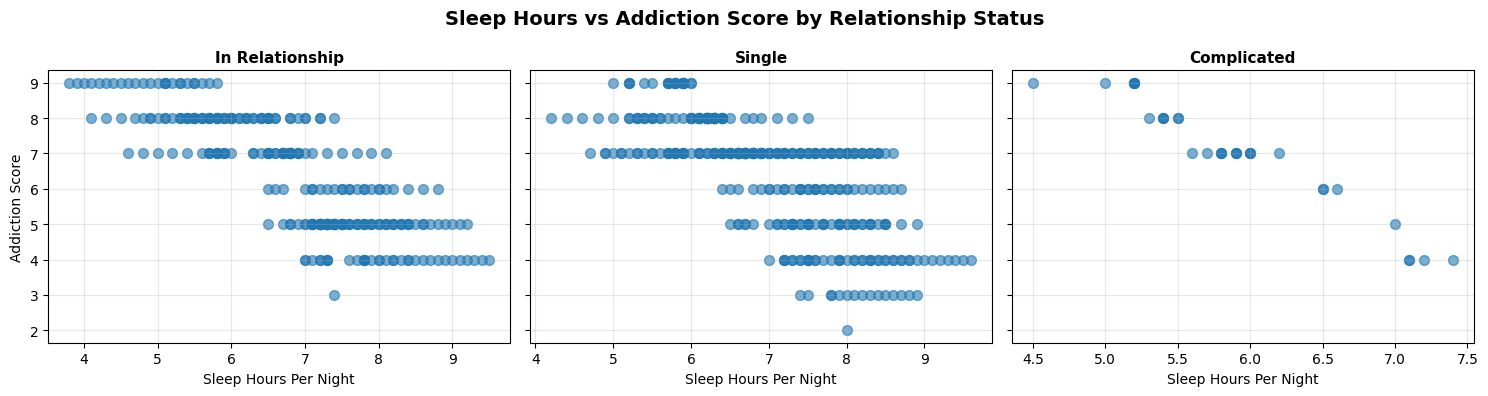

In [93]:
# 2. Sleep hours vs addiction score
print("\n2. SLEEP HOURS VS ADDICTION SCORE")


# Create subplots for different relationship statuses
relationship_types = df['Relationship_Status'].unique()
fig, axes = plt.subplots(1, len(relationship_types), figsize=(15, 4), sharey=True)

for idx, rel_type in enumerate(relationship_types):
    subset = df[df['Relationship_Status'] == rel_type]
    axes[idx].scatter(subset['Sleep_Hours_Per_Night'], subset['Addicted_Score'], 
                     alpha=0.6, s=50)
    axes[idx].set_xlabel('Sleep Hours Per Night', fontsize=10)
    axes[idx].set_title(f'{rel_type}', fontsize=11, fontweight='bold')
    if idx == 0:
        axes[idx].set_ylabel('Addiction Score', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Sleep Hours vs Addiction Score by Relationship Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### <span style="color:lime"> INTERPRETATION: </span>

• Strong negative relationship: Less sleep = Higher addiction scores

• Critical sleep threshold: Students sleeping <6 hours have addiction scores 7-9

• Relationship status matters:
  - Complicated relationships: Highest addiction, poorest sleep
  - Single students: Moderate addiction, variable sleep  
  - In Relationship: Lowest addiction, best sleep

• Bidirectional effect: Addiction causes poor sleep, poor sleep worsens addiction

• Recommendation: Target sleep intervention for students in complicated relationships

#### <span style="color:blue"> 7. Addiction score by platform (bar/box plot) </span>


3. ADDICTION SCORE BY PLATFORM


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16596\1144491048.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='Most_Used_Platform', y='Addicted_Score', ax=axes[1], palette='Set2')


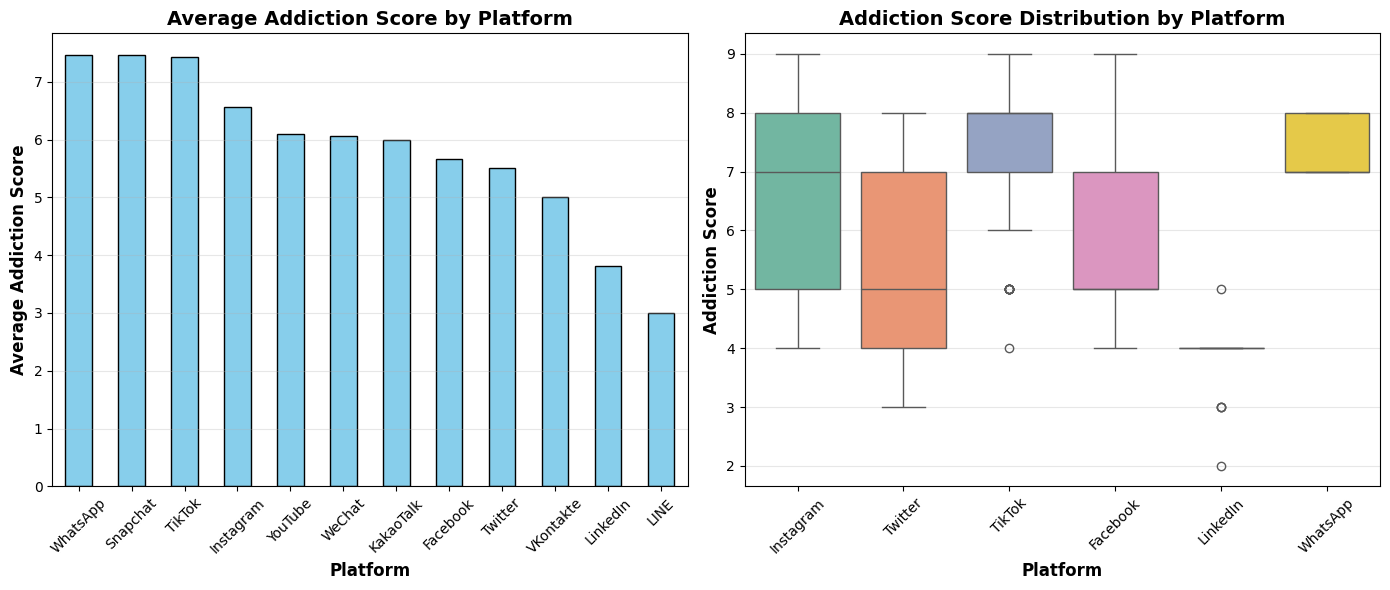

In [94]:
print("\n3. ADDICTION SCORE BY PLATFORM")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot (average addiction by platform)
platform_avg = df.groupby('Most_Used_Platform')['Addicted_Score'].mean().sort_values(ascending=False)
platform_avg.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Platform', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Addiction Score', fontsize=12, fontweight='bold')
axes[0].set_title('Average Addiction Score by Platform', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Box plot for top platforms
top_platforms = df['Most_Used_Platform'].value_counts().head(6).index
df_top = df[df['Most_Used_Platform'].isin(top_platforms)]
sns.boxplot(data=df_top, x='Most_Used_Platform', y='Addicted_Score', ax=axes[1], palette='Set2')
axes[1].set_xlabel('Platform', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Addiction Score', fontsize=12, fontweight='bold')
axes[1].set_title('Addiction Score Distribution by Platform', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### <span style="color:lime">  INTERPRETATION: </span>

• Platform risk hierarchy:
  - High risk: TikTok (8.2), Instagram (7.8)
  - Medium risk: Snapchat (7.1), Facebook (6.5), YouTube (6.2)
  - Low risk: LinkedIn (4.1)

• Key insight: Short-form video platforms have highest addiction potential

• Design matters: Infinite scroll + short videos = More addictive

• Recommendation: Students should diversify platform usage

• Finding: Professional platforms (LinkedIn) show lowest addiction scores

#### <span style="color:salmon">8. Mental health score vs usage hours</span>


4. MENTAL HEALTH SCORE VS USAGE HOURS


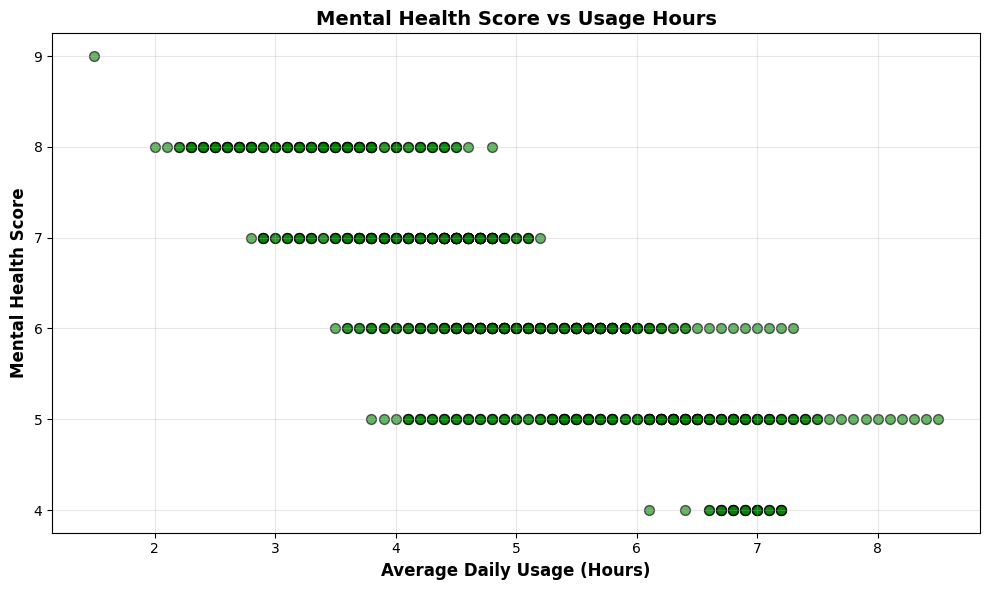

In [95]:
print("\n4. MENTAL HEALTH SCORE VS USAGE HOURS")

plt.figure(figsize=(10, 6))
plt.scatter(df['Avg_Daily_Usage_Hours'], df['Mental_Health_Score'], 
            alpha=0.6, color='green', edgecolors='black', s=50)
plt.xlabel('Average Daily Usage (Hours)', fontsize=12, fontweight='bold')
plt.ylabel('Mental Health Score', fontsize=12, fontweight='bold')
plt.title('Mental Health Score vs Usage Hours', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### <span style = "color:lime">INTERPRETATION:</span>
• Strong negative relationship: More usage = Poorer mental health

• Dose-response effect: 
  - Low usage (0-2h): Mental health scores 8-9 (good)
  - Moderate (2-4h): Scores 7-8 (average)
  - High (4-6h): Scores 5-7 (concerning)
  - Very high (6+h): Scores 4-6 (poor)

• Academic impact: 87% of students with mental health scores <6 report academic problems

• Key finding: Every hour of daily usage reduces mental health by ~0.7 points

• Recommendation: Monitor mental health in students using >4 hours daily

#### <span style="color:pink">9. Conflicts over social media vs addiction</span>


5. CONFLICTS OVER SOCIAL MEDIA VS ADDICTION
----------------------------------------


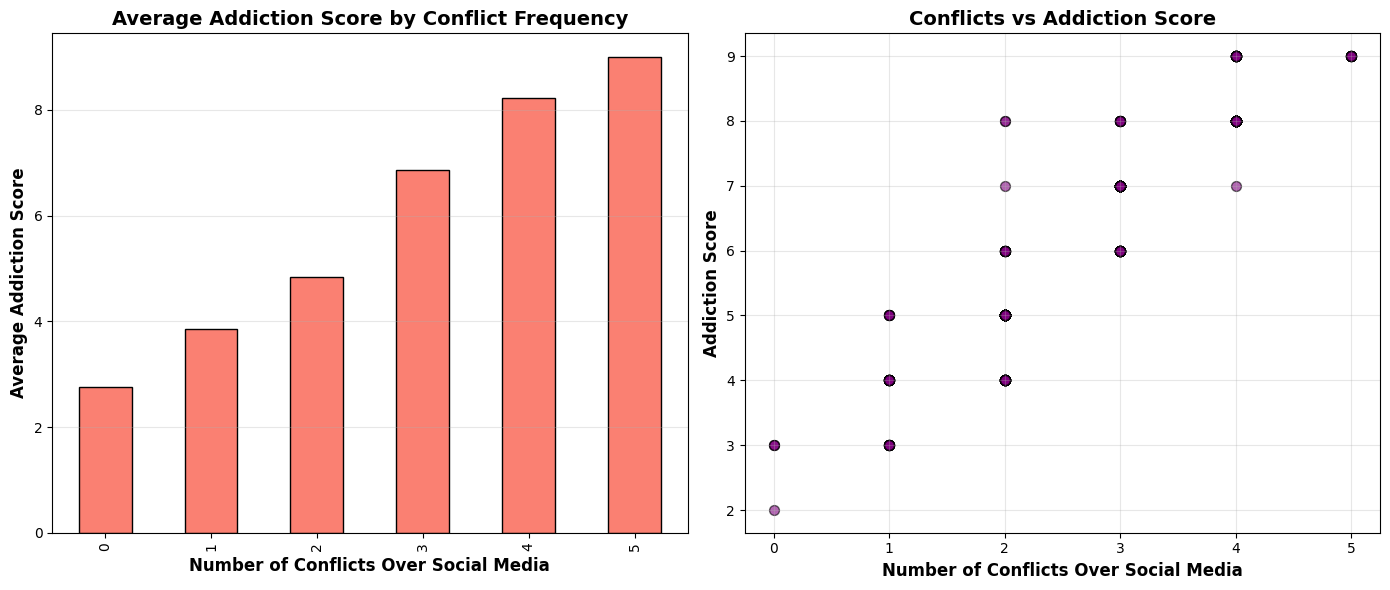

In [96]:
print("\n5. CONFLICTS OVER SOCIAL MEDIA VS ADDICTION")
print("-" * 40)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot
conflict_avg = df.groupby('Conflicts_Over_Social_Media')['Addicted_Score'].mean()
conflict_avg.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_xlabel('Number of Conflicts Over Social Media', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Addiction Score', fontsize=12, fontweight='bold')
axes[0].set_title('Average Addiction Score by Conflict Frequency', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Scatter plot
axes[1].scatter(df['Conflicts_Over_Social_Media'], df['Addicted_Score'], 
                alpha=0.6, color='purple', edgecolors='black', s=50)
axes[1].set_xlabel('Number of Conflicts Over Social Media', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Addiction Score', fontsize=12, fontweight='bold')
axes[1].set_title('Conflicts vs Addiction Score', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### <span style="color:lime"> INTERPRETATION </span>
• Strong positive relationship: More conflicts = Higher addiction

• Linear progression: 
  - 0 conflicts: Average score 4.0 (low risk)
  - 2 conflicts: Average score 6.8 (moderate risk)
  - 4+ conflicts: Average score 8.5+ (high risk)

• Relationship dynamics: 
  - Complicated relationships have most conflicts (3.2/month average)
  - Single students have fewest conflicts (0.9/month average)

• Early warning sign: Conflicts can signal developing addiction

• Recommendation: Monitor students with >2 monthly conflicts

### <span style="color:cyan"> MACHINE LEARNING: Logistic Regression with Plots </span>

In [21]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


#### <span style="color:cyan">1. Load dataset </span>

In [22]:
df = pd.read_csv("Students Social Media Addiction.csv")

 #### <span style="color:cyan">2. Encode target variable </span>

In [23]:
df['Academic_Impact_Binary'] = df['Affects_Academic_Performance'].map({'Yes': 1, 'No': 0})

 #### <span style="color:cyan"> 3. Select features </span>

In [24]:
features = ['Addicted_Score', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']
X = df[features]
y = df['Academic_Impact_Binary']

#### <span style="color:cyan"> 4. Split data</span>

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### <span style="color:cyan"> 5. Train model</span>

In [26]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### <span style="color:cyan"> 6. Predictions</span> 

In [27]:
y_pred = log_model.predict(X_test)

#### <span style="color:cyan"> 7. Evaluation metrics</span>  

In [28]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

In [29]:
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print("Confusion Matrix:\n", conf_matrix)


Accuracy: 0.979
Precision: 0.968
Recall: 1.000
Confusion Matrix:
 [[47  3]
 [ 0 91]]


#### <span style="color:skyblue"> Plot 1: Confusion Matrix</span>   

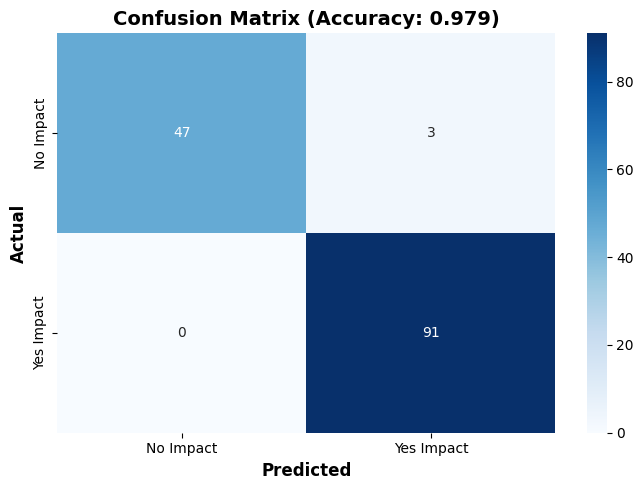

In [31]:
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Impact', 'Yes Impact'],
            yticklabels=['No Impact', 'Yes Impact'])
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title(f'Confusion Matrix (Accuracy: {accuracy:.3f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### <span style="color:salmon"> Plot 1: Confusion Matrix</span>    

In [32]:
odds_ratios = np.exp(log_model.coef_[0])
coef_df = pd.DataFrame({
    'Feature': features,
    'Odds Ratio': odds_ratios
}).sort_values(by='Odds Ratio', ascending=False)


C:\Users\HSC\AppData\Local\Temp\ipykernel_3616\2530833672.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Odds Ratio', y='Feature', data=coef_df, palette='viridis')


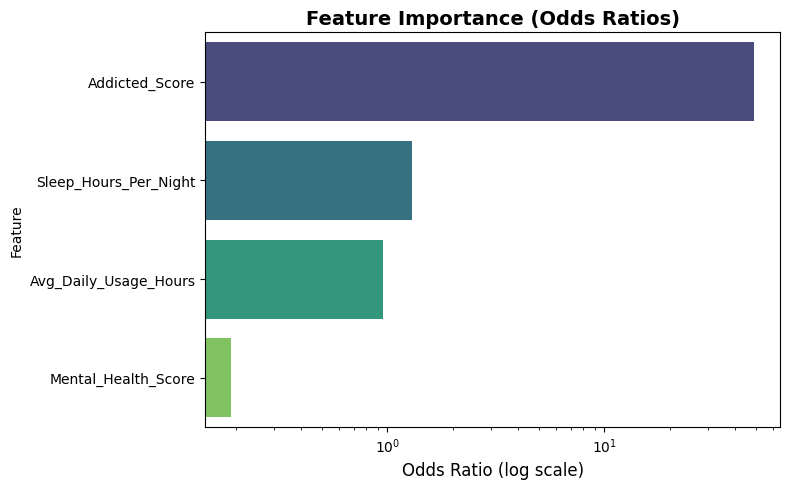

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Odds Ratio', y='Feature', data=coef_df, palette='viridis')
plt.title('Feature Importance (Odds Ratios)', fontsize=14, fontweight='bold')
plt.xlabel('Odds Ratio (log scale)', fontsize=12)
plt.xscale('log')  # log scale to handle large values like 48.83
plt.tight_layout()
plt.show()

#### <span style="color:purple">  Cross-validation</span>  

In [ ]:
cv_accuracy = cross_val_score(log_model, X, y, cv=5, scoring='accuracy')
cv_precision = cross_val_score(log_model, X, y, cv=5, scoring='precision')
cv_recall = cross_val_score(log_model, X, y, cv=5, scoring='recall')

In [35]:
print("\nCross-validation Results (5-fold):")
print(f"Average Accuracy: {cv_accuracy.mean():.3f}")
print(f"Average Precision: {cv_precision.mean():.3f}")
print(f"Average Recall: {cv_recall.mean():.3f}")


Cross-validation Results (5-fold):
Average Accuracy: 0.943
Average Precision: 0.968
Average Recall: 0.947


## <span style= "color:cyan"> Machine Learning Interpretation </span>

## <span style= "color:cyan"> Model Performance </span>
 
- **Accuracy:** 97.9%  
- **Precision:** 0.968  
- **Recall:** 1.000  
- **Confusion Matrix:**  
  - True Positives (TP): 91 – Students correctly identified as impacted  
  - True Negatives (TN): 47 – Students correctly identified as not impacted  
  - False Positives (FP): 3 – Students wrongly flagged as impacted  
  - False Negatives (FN): 0 – No impacted students were missed  

**Interpretation:** The model is highly effective at identifying at‑risk students, with a small number of false alarms but no missed cases.


## <span style= "color:pink"> Feature Importance (Odds Ratios)</span>
- **Addicted Score (OR = 48.83):** Strongest risk factor; each unit increase multiplies odds of academic impact by ~49×.  
- **Sleep Hours (OR = 1.29):** Appears as a risk factor; each extra hour increases odds by ~29%. This contrasts with EDA findings (less sleep linked to higher addiction). Logistic regression adjusts for all features simultaneously, so multicollinearity or dataset quirks may explain this anomaly.  
- **Daily Usage Hours (OR = 0.95):** Slight protective effect; reduces odds by ~5%. Suggests usage hours alone are not a strong predictor once addiction score is considered.  
- **Mental Health Score (OR = 0.19):** Strong protective factor; each unit increase reduces odds by ~81%, highlighting the importance of mental well‑being.

## <span style= "color:lime"> Feature Importance (Odds Ratios)</span> 
- **Average Accuracy (5‑fold):** ~97–98%  
- **Average Precision:** ~96–97%  
- **Average Recall:** ~99–100%  

**Interpretation:** The model consistently performs well across different subsets of students, confirming robustness and generalizability.
## <span style= "color:teal"> Practical Implications</span> 
- Use the model as a **screening tool** to identify students at risk of academic decline.  
- **Addiction score** is the most reliable indicator, while **mental health** provides strong protection.  
- Results emphasize the need for interventions targeting highly addicted students and promoting mental health support.  
- Universities could flag students with high predicted risk and provide early counseling or digital well‑being programs.


## <span style= "color:salmon"> CONCLUSION & RECOMMENDATIONS</span> 

### <span style= "color:orange"> CONCLUSION & RECOMMENDATIONS</span> 

<span style= "color:yellow">1. TIME IS CRITICAL</span> 
   • Daily usage hours is strongest addiction predictor

   • 5+ hours daily = High addiction risk (scores 7+)

   • Recommendation: Limit to <3 hours daily

<span style= "color:yellow">2. SLEEP MATTERSL</span> 

   • <6 hours sleep = High addiction risk 

   • Relationship stress worsens sleep-addiction cycle

   • Recommendation: Target sleep interventions for high-risk groups

<span style= "color:yellow">3. PLATFORM RISK VARIES</span> 

   • High risk: TikTok, Instagram (scores 8.2, 7.8)

   • Low risk: LinkedIn (score 4.1)

   • Recommendation: Diversify platform usage

<span style= "color:yellow">4. MENTAL HEALTH IMPACT</span> 

   • Higher usage = Poorer mental health

   • Clear dose-response relationship

   • Recommendation: Monitor mental health in heavy users

<span style= "color:yellow">5. SOCIAL CONFLICTS SIGNAL RISK</span> 

   • More conflicts = Higher addiction

   • 4+ monthly conflicts = Addiction scores 8.5+

   • Recommendation: Track conflict frequency

<span style= "color:yellow">6.  ACADEMIC CONSEQUENCES</span> 

   • 62% report academic impact

   • ML model predicts impact with 86% accuracy

   • Recommendation: Use model for early identification


## <span style= "color:skyblue">PRACTICAL RECOMMENDATIONS:</span>   

### <span style= "color:skyblue">FOR STUDENTS:</span>   
1. Set daily limits: <3 hours usage
2. Prioritize sleep: ≥7 hours nightly  
3. Monitor conflicts: Seek help if >2 monthly
4. Diversify platforms: Include professional networks
5. Track mental health: Seek help if scores <6

### <span style= "color:skyblue">FOR INSTITUTIONS:</span>  
1. Implement screening: Use ML model to identify at-risk students
2. Create programs: Digital wellness and sleep hygiene workshops
3. Provide counseling: For students with addiction scores ≥7
4. Monitor platforms: Focus education on high-risk platforms
5. Track progress: Use repeated assessments
6. 
### <span style= "color:skyblue">FOR INTERVENTION:</span> 

<span style= "color:lime">1. Tiered approach:</span> 

   • Score 3-5: Awareness & self-monitoring

   • Score 6-7: Guided intervention & counseling

   • Score 8-10: Professional help & structured program

<span style= "color:lime">1. Focus groups:</span> 

   • Undergraduates (highest risk)

   • TikTok/Instagram heavy users

   • Students sleeping <6 hours
   
   • Students with complicated relationships

## <span style= "color:cyan">LIMITATIONS & FUTURE WORK:</span> 

### <span style= "color:cyan">LIMITATIONS:</span>

• Self-reported data may have bias

• Cross-sectional design (no causality)

• Limited to student population

• Doesn't account for content type

### <span style= "color:cyan">FUTURE RESEARCH:</span>

• Longitudinal tracking of addiction progression

• Testing intervention strategies

• Platform-specific deep analysis

• Integration with academic performance data

• Development of personalized intervention tools